In [3]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

Found cached dataset csv (C:/Users/theim/.cache/huggingface/datasets/lukebarousse___csv/lukebarousse--data_jobs-20095235c13fb98d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1)


  0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
# Only et the US Data Analyst job postings
df_US_DA = df[df['job_country'] == 'United States'].copy()

In [5]:
df_skills = df_US_DA.explode('job_skills').copy()

# Count how many times each skill appears for each job title
df_skills_count = (
    df_skills
    .groupby(['job_title_short', 'job_skills'])
    .size()
    .reset_index(name='skill_count')
)

# Total number of job postings for each job title
total_jobs = df_US_DA.groupby('job_title_short').size()

# Map the totals onto the skills dataframe
df_skills_count['total_jobs'] = df_skills_count['job_title_short'].map(total_jobs)

# Calculate percentage
df_skills_count['skill_percent'] = (
    df_skills_count['skill_count'] / df_skills_count['total_jobs'] * 100
).round(1)

# Optional: sort by percentage
df_skills_count = df_skills_count.sort_values(
    by=['job_title_short', 'skill_percent'], 
    ascending=[True, False]
)

In [6]:
df_skills_count

,job_title_short,job_skills,skill_count,total_jobs,skill_percent
130,Business Analyst,sql,3564,7382,48.3
40,Business Analyst,excel,3128,7382,42.4
140,Business Analyst,tableau,2213,7382,30.0
95,Business Analyst,power bi,1558,7382,21.1
99,Business Analyst,python,1409,7382,19.1
...,...,...,...,...,...
1853,Software Engineer,unity,2,1814,0.1
1862,Software Engineer,watson,2,1814,0.1
1863,Software Engineer,webex,1,1814,0.1
1865,Software Engineer,wire,2,1814,0.1


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


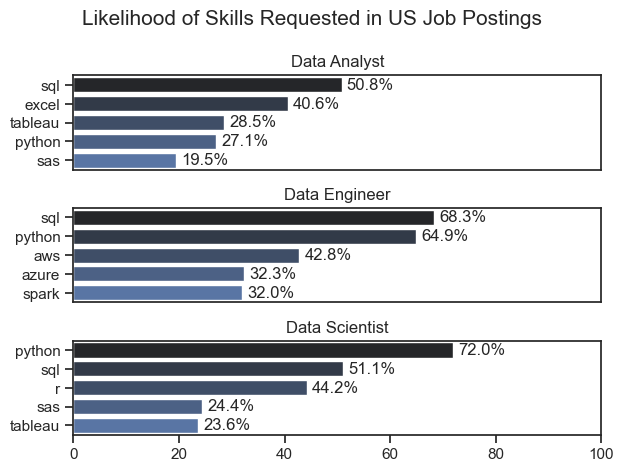

In [ ]:
# Jobs that will be plotted
data_jobs = (
    df_skills_count['job_title_short']
    .value_counts()
    .head(3)
    .index
    .tolist()
)
data_jobs = sorted(data_jobs[:3])
sns.set_theme(style='ticks')

fig, ax = plt.subplots(len(data_jobs), 1)

for i, job_title in enumerate(data_jobs):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    sns.barplot(
        data=df_plot,
        x='skill_percent', 
        y='job_skills', 
        ax=ax[i], 
        palette='dark:b',
        units='skill_percent'
    )
    ax[i].set_title(data_jobs[i])
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 100)

    for n, v, in enumerate(df_plot['skill_percent']):
        ax[i].text(v+1, n, f'{v}%', va='center')

    if i != len(data_jobs) -1:
        ax[i].set_xticks([])

fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout()

In [27]:
data_jobs

['Data Scientist', 'Data Engineer', 'Data Analyst']